In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/skaters.csv")

In [5]:
df.head()

,playerId,season,name,team,position,situation,games_played,icetime,shifts,gameScore,...,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts
0,8480950,2023,Ilya Lyubushkin,TOR,D,other,74,2881.0,56.0,5.08,...,18.00,21.61,195.0,191.0,0.11,0.02,3.0,1.0,3.0,1.0
1,8480950,2023,Ilya Lyubushkin,TOR,D,all,74,76034.0,1717.0,4.47,...,176.13,171.61,3226.0,3132.0,0.00,0.00,0.0,0.0,0.0,0.0
2,8480950,2023,Ilya Lyubushkin,TOR,D,5on5,74,61758.0,1389.0,4.47,...,107.09,104.80,2302.0,2303.0,6.54,0.64,140.0,11.0,108.0,8.0
3,8480950,2023,Ilya Lyubushkin,TOR,D,4on5,74,11271.0,259.0,3.43,...,4.28,27.86,68.0,482.0,0.11,0.00,4.0,0.0,3.0,0.0
4,8480950,2023,Ilya Lyubushkin,TOR,D,5on4,74,124.0,13.0,3.45,...,6.03,1.37,106.0,19.0,0.00,0.00,0.0,0.0,0.0,0.0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4620 entries, 0 to 4619
Columns: 154 entries, playerId to fenwickAgainstAfterShifts
dtypes: float64(147), int64(3), str(4)
memory usage: 5.5 MB


In [18]:
df.describe()

,playerId,season,games_played,icetime,shifts,gameScore,onIce_xGoalsPercentage,offIce_xGoalsPercentage,onIce_corsiPercentage,offIce_corsiPercentage,...,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts
count,4.620000e+03,4620.0,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000,...,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000,4620.000000
mean,8.479007e+06,2023.0,51.104978,20230.578355,422.293074,20.044771,0.433734,0.465942,0.437405,0.464132,...,42.676481,43.156266,856.131602,864.622944,0.398054,0.159528,9.058225,4.039394,6.867749,3.153030
std,2.848170e+03,0.0,29.016811,29125.786977,600.708821,24.884332,0.293315,0.268342,0.282704,0.260509,...,57.823361,57.517343,1198.338781,1197.198244,1.158608,0.427615,25.491375,10.185897,19.380424,7.960973
min,8.470600e+06,2023.0,1.000000,0.000000,0.000000,-9.300000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.476956e+06,2023.0,24.750000,469.000000,15.000000,1.060000,0.150000,0.310000,0.180000,0.310000,...,2.480000,2.180000,37.000000,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.479326e+06,2023.0,61.000000,4402.500000,88.000000,9.765000,0.470000,0.490000,0.470000,0.490000,...,11.505000,12.670000,132.000000,139.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.481517e+06,2023.0,78.000000,33273.000000,741.250000,31.157500,0.580000,0.570000,0.580000,0.560000,...,82.047500,83.225000,1748.250000,1796.750000,0.110000,0.040000,2.000000,1.000000,2.000000,1.000000
max,8.484911e+06,2023.0,83.000000,127387.000000,2501.000000,154.730000,1.000000,1.000000,1.000000,1.000000,...,271.990000,230.830000,4797.000000,4337.000000,10.490000,3.870000,232.000000,67.000000,170.000000,59.000000


In [25]:
print(df.columns.tolist())

['playerId', 'season', 'name', 'team', 'position', 'situation', 'games_played', 'icetime', 'shifts', 'gameScore', 'onIce_xGoalsPercentage', 'offIce_xGoalsPercentage', 'onIce_corsiPercentage', 'offIce_corsiPercentage', 'onIce_fenwickPercentage', 'offIce_fenwickPercentage', 'iceTimeRank', 'I_F_xOnGoal', 'I_F_xGoals', 'I_F_xRebounds', 'I_F_xFreeze', 'I_F_xPlayStopped', 'I_F_xPlayContinuedInZone', 'I_F_xPlayContinuedOutsideZone', 'I_F_flurryAdjustedxGoals', 'I_F_scoreVenueAdjustedxGoals', 'I_F_flurryScoreVenueAdjustedxGoals', 'I_F_primaryAssists', 'I_F_secondaryAssists', 'I_F_shotsOnGoal', 'I_F_missedShots', 'I_F_blockedShotAttempts', 'I_F_shotAttempts', 'I_F_points', 'I_F_goals', 'I_F_rebounds', 'I_F_reboundGoals', 'I_F_freeze', 'I_F_playStopped', 'I_F_playContinuedInZone', 'I_F_playContinuedOutsideZone', 'I_F_savedShotsOnGoal', 'I_F_savedUnblockedShotAttempts', 'penalties', 'I_F_penalityMinutes', 'I_F_faceOffsWon', 'I_F_hits', 'I_F_takeaways', 'I_F_giveaways', 'I_F_lowDangerShots', 'I_F_

In [19]:
df.isnull().sum()

playerId                     0
season                       0
name                         0
team                         0
position                     0
                            ..
xGoalsAgainstAfterShifts     0
corsiForAfterShifts          0
corsiAgainstAfterShifts      0
fenwickForAfterShifts        0
fenwickAgainstAfterShifts    0
Length: 154, dtype: int64

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.fillna(0, inplace=True)

,playerId,season,name,team,position,situation,games_played,icetime,shifts,gameScore,...,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts
0,8480950,2023,Ilya Lyubushkin,TOR,D,other,74,2881.0,56.0,5.08,...,18.00,21.61,195.0,191.0,0.11,0.02,3.0,1.0,3.0,1.0
1,8480950,2023,Ilya Lyubushkin,TOR,D,all,74,76034.0,1717.0,4.47,...,176.13,171.61,3226.0,3132.0,0.00,0.00,0.0,0.0,0.0,0.0
2,8480950,2023,Ilya Lyubushkin,TOR,D,5on5,74,61758.0,1389.0,4.47,...,107.09,104.80,2302.0,2303.0,6.54,0.64,140.0,11.0,108.0,8.0
3,8480950,2023,Ilya Lyubushkin,TOR,D,4on5,74,11271.0,259.0,3.43,...,4.28,27.86,68.0,482.0,0.11,0.00,4.0,0.0,3.0,0.0
4,8480950,2023,Ilya Lyubushkin,TOR,D,5on4,74,124.0,13.0,3.45,...,6.03,1.37,106.0,19.0,0.00,0.00,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4615,8477488,2023,Brett Pesce,CAR,D,other,70,2731.0,48.0,30.97,...,12.35,11.97,125.0,84.0,0.04,0.00,1.0,0.0,1.0,0.0
4616,8477488,2023,Brett Pesce,CAR,D,all,70,85212.0,1725.0,41.27,...,172.40,122.21,3431.0,2154.0,0.00,0.00,0.0,0.0,0.0,0.0
4617,8477488,2023,Brett Pesce,CAR,D,5on5,70,72590.0,1415.0,41.27,...,107.20,80.61,2625.0,1751.0,4.63,0.35,115.0,17.0,89.0,12.0
4618,8477488,2023,Brett Pesce,CAR,D,4on5,70,9349.0,217.0,40.17,...,3.63,19.19,63.0,222.0,0.45,0.05,7.0,1.0,6.0,1.0


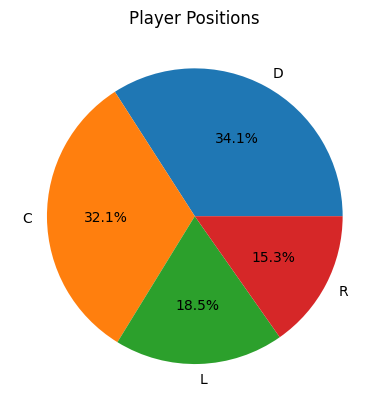

In [22]:
df["position"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Player Positions")
plt.show()

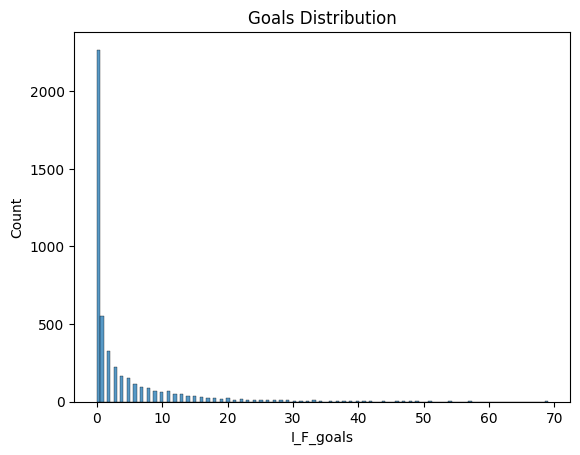

In [ ]:
sns.histplot(df["I_F_goals"], bins=20)

plt.title("Goals Distribution")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

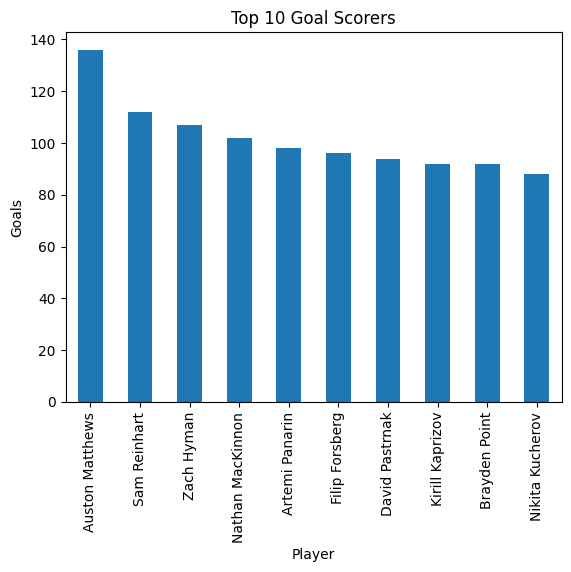

In [30]:
top_players = df.groupby("name")["I_F_goals"] \
                .sum() \
                .sort_values(ascending=False) \
                .head(10)

top_players.plot(kind='bar')

plt.title("Top 10 Goal Scorers")
plt.xlabel("Player")
plt.ylabel("Goals")

plt.show()

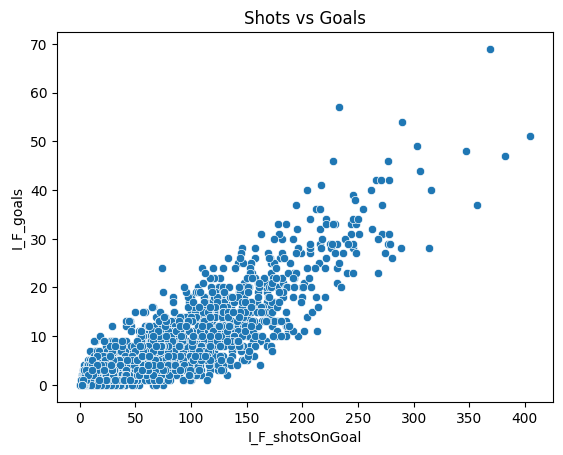

In [31]:
sns.scatterplot(
    x="I_F_shotsOnGoal",
    y="I_F_goals",
    data=df
)

plt.title("Shots vs Goals")

plt.show()

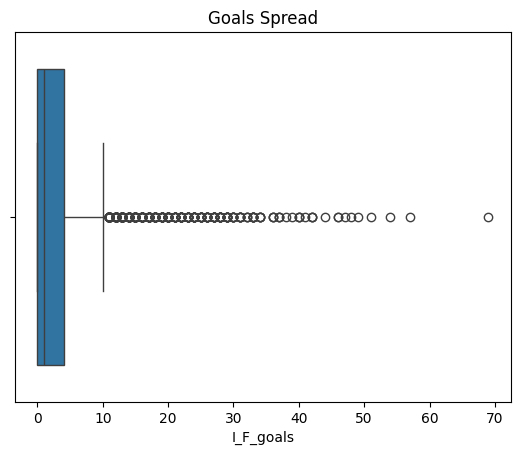

In [32]:
sns.boxplot(x=df["I_F_goals"])

plt.title("Goals Spread")

plt.show()

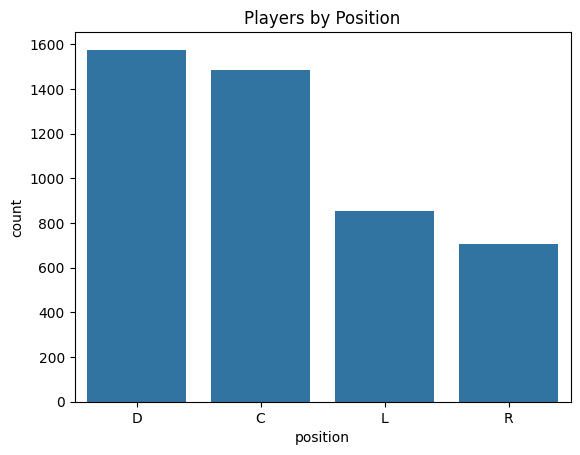

In [33]:
sns.countplot(x="position", data=df)

plt.title("Players by Position")

plt.show()

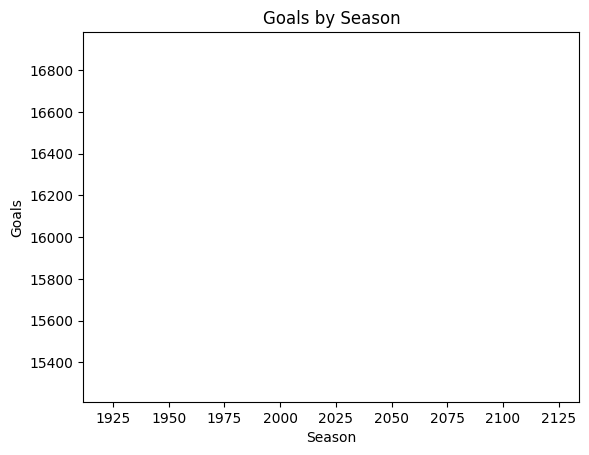

In [34]:
season_goals = df.groupby("season")["I_F_goals"].sum()

season_goals.plot()

plt.title("Goals by Season")
plt.xlabel("Season")
plt.ylabel("Goals")

plt.show()

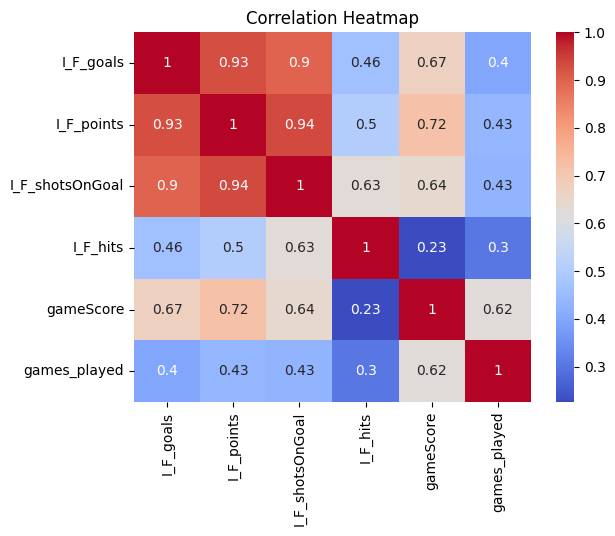

In [35]:
selected = df[[
    "I_F_goals",
    "I_F_points",
    "I_F_shotsOnGoal",
    "I_F_hits",
    "gameScore",
    "games_played"
]]

corr = selected.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

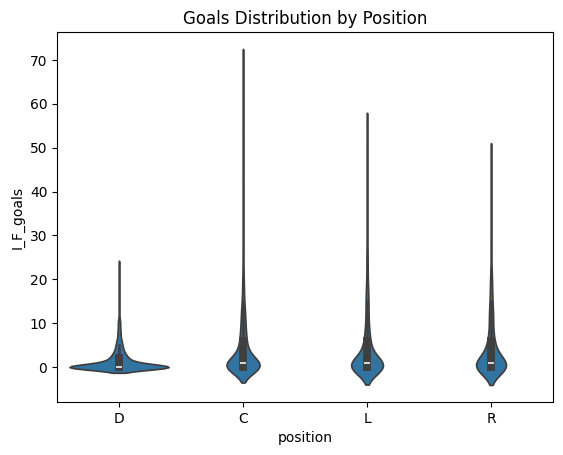

In [36]:
sns.violinplot(
    x="position",
    y="I_F_goals",
    data=df
)

plt.title("Goals Distribution by Position")

plt.show()

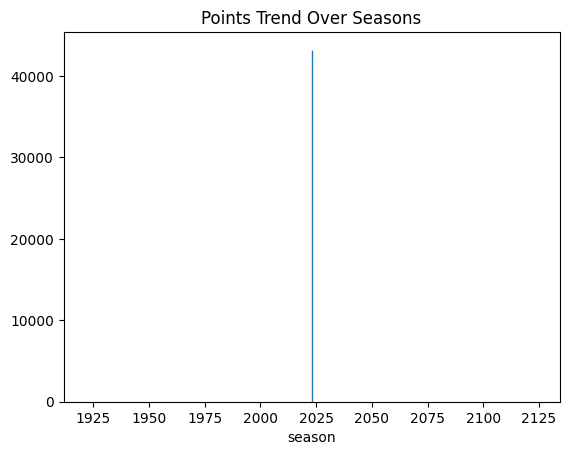

In [37]:
season_points = df.groupby("season")["I_F_points"].sum()

season_points.plot.area()

plt.title("Points Trend Over Seasons")

plt.show()

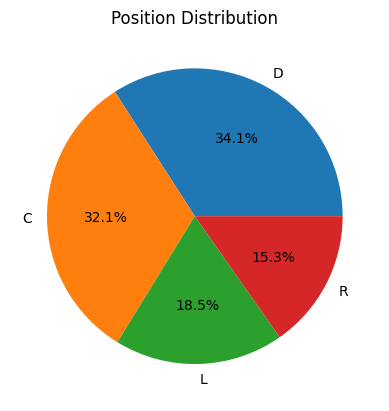

In [38]:
position_counts = df["position"].value_counts()

position_counts.plot.pie(autopct='%1.1f%%')

plt.title("Position Distribution")

plt.ylabel("")

plt.show()

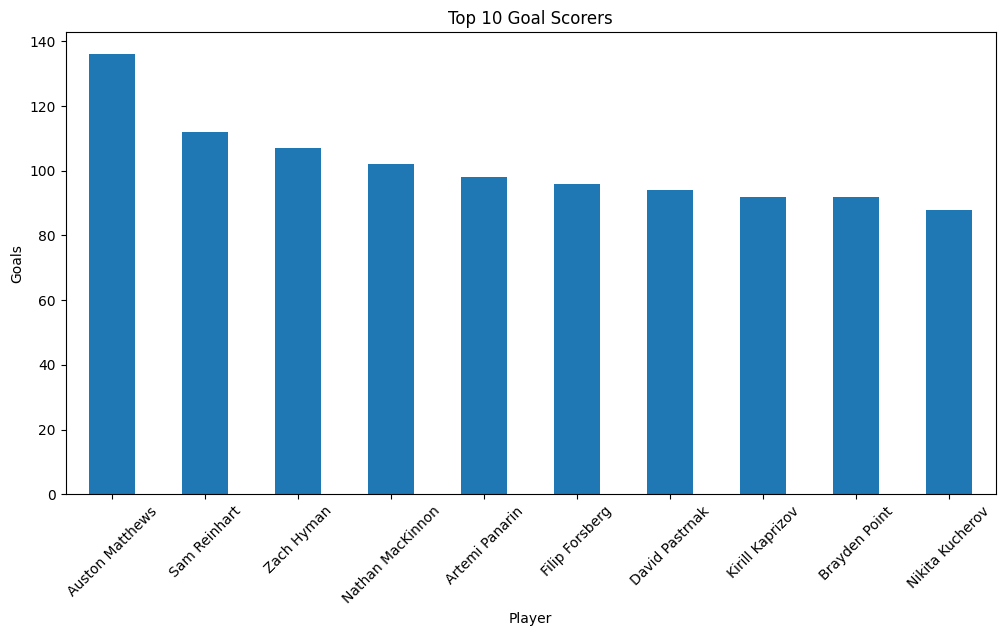

In [40]:
top_players = df.groupby("name")["I_F_goals"] \
                .sum() \
                .sort_values(ascending=False) \
                .head(10)

plt.figure(figsize=(12,6))

top_players.plot(kind='bar')

plt.title("Top 10 Goal Scorers")
plt.xlabel("Player")
plt.ylabel("Goals")

plt.xticks(rotation=45)

plt.show()

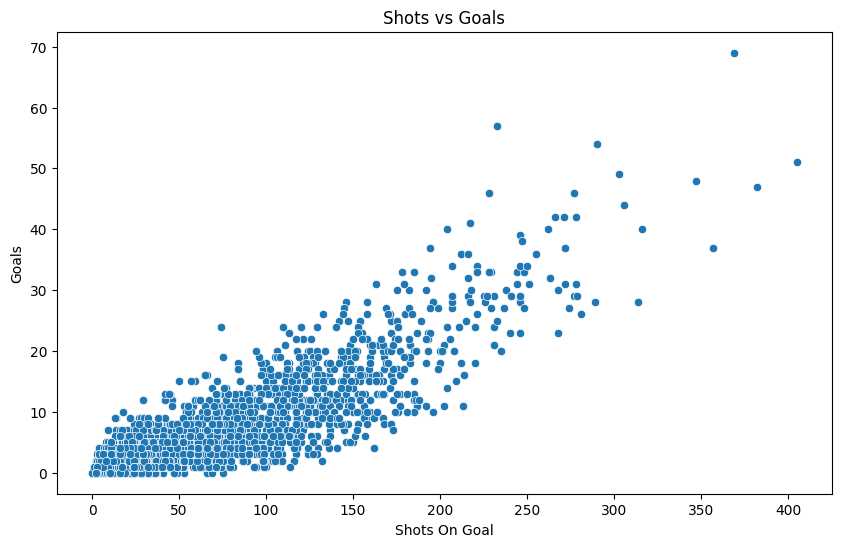

In [41]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="I_F_shotsOnGoal",
    y="I_F_goals",
    data=df
)

plt.title("Shots vs Goals")
plt.xlabel("Shots On Goal")
plt.ylabel("Goals")

plt.show()

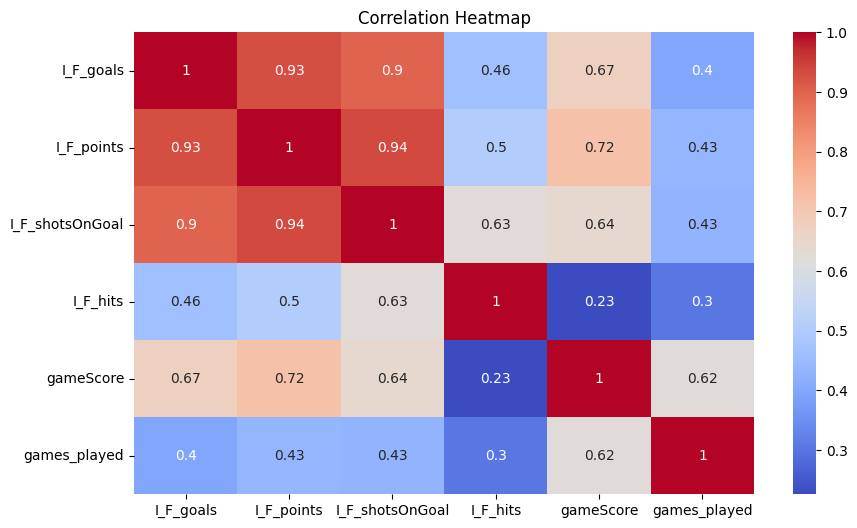

In [42]:
selected = df[[
    "I_F_goals",
    "I_F_points",
    "I_F_shotsOnGoal",
    "I_F_hits",
    "gameScore",
    "games_played"
]]

corr = selected.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

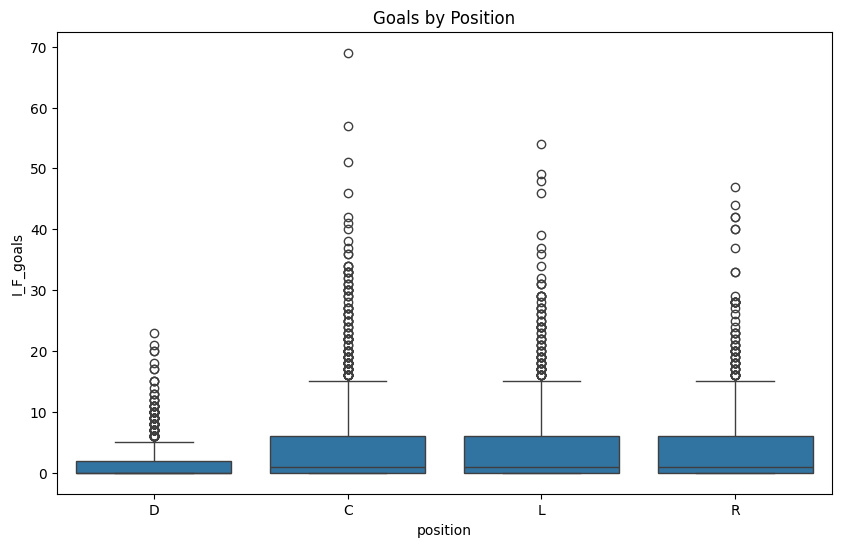

In [43]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="position",
    y="I_F_goals",
    data=df
)

plt.title("Goals by Position")

plt.show()

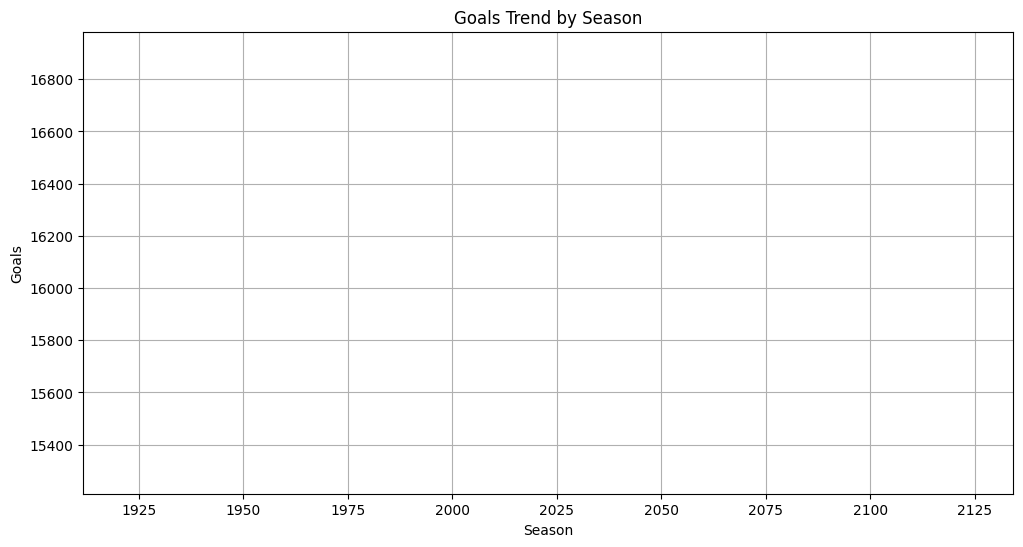

In [44]:
season_goals = df.groupby("season")["I_F_goals"].sum()

plt.figure(figsize=(12,6))

season_goals.plot()

plt.title("Goals Trend by Season")
plt.xlabel("Season")
plt.ylabel("Goals")

plt.grid(True)

plt.show()

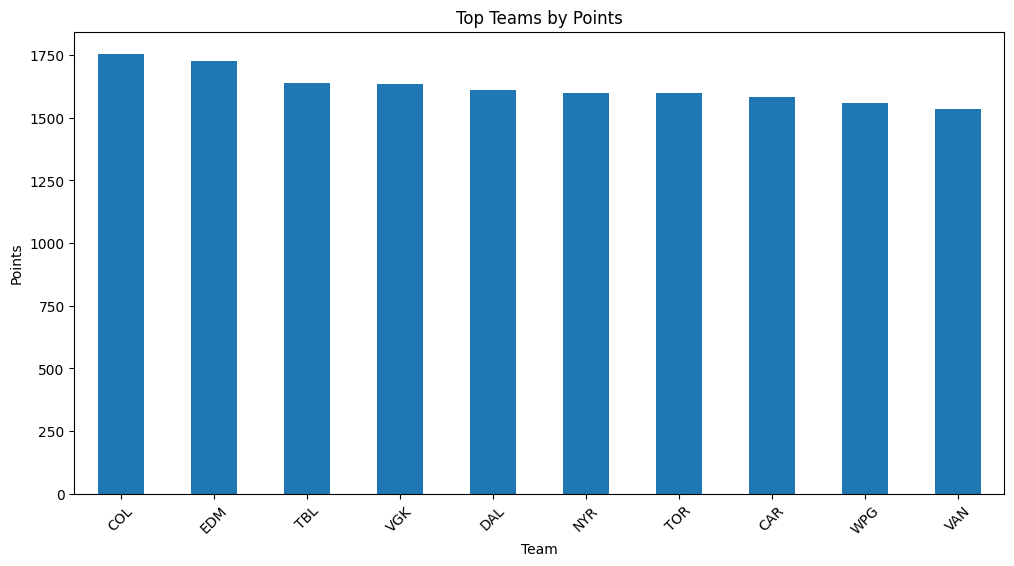

In [45]:
top_teams = df.groupby("team")["I_F_points"] \
              .sum() \
              .sort_values(ascending=False) \
              .head(10)

plt.figure(figsize=(12,6))

top_teams.plot(kind='bar')

plt.title("Top Teams by Points")
plt.xlabel("Team")
plt.ylabel("Points")

plt.xticks(rotation=45)

plt.show()